In [2]:
from pysarflow import Sentinel1GRDProcessor
import matplotlib.pyplot as plt

In [3]:
# Defining area of interest in geojson format
aoi_polygon = {"type":"Polygon",
               "coordinates":[[
                   [-118.185081,34.137719],
                   [-118.185081,34.266631],
                   [-117.983208,34.266631],
                   [-117.983208,34.137719],
                   [-118.185081,34.137719]]]}

# Creating processor instance from Sentinel1GRDProcessor class
processor = Sentinel1GRDProcessor()

# Running search data function using processor instance
processor.search_data(aoi=aoi_polygon, datetime = "2025-01-05/2025-01-10")

/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow/.venv/lib/python3.12/site-packages/pystac_client/item_search.py:881: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [4]:
import os
os.chdir("/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow/")
!pwd

/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow


In [5]:
processor = Sentinel1GRDProcessor()
# Reading Sentinel-1 GRD data
# 2014 SAR data
# zip_safe_path = r"C:\Users\Ethel Ogallo\Documents\CDE\PLUS\SS25\practice_softwaredev\pysarflow\docs\ethel_temp\S1A_IW_GRDH_1SSV_20141004T005844_20141004T005913_002673_002FAB_E4BC_COG.zip"
# safe_extract_path= r"C:\Temp\SAR_old"

# 2025 SAR data
# zip_safe_path = r'C:\Users\Ethel Ogallo\Documents\CDE\PLUS\SS25\practice_softwaredev\pysarflow\docs\ethel_temp\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.zip'
# safe_extract_path= r"C:\Temp\SAR"

# if reading zip file
# zip_safe_path = "docs/data/sarsen/S1B_IW_GRDH_1SDV_20211223T051122_20211223T051147_030148_039993_5371.SAFE"
zip_safe_path = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
safe_extract_path= "docs/data/"
ds = processor.read_grd_data(zip_safe_path,safe_extract_path)

# #if reading safe file directly
# safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241209T015852_20241209T015917_056909_06FD49_AE78.SAFE"
# ds = processor.read_grd_data(zip_safe_path)

print(ds)

Loading band VV from docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/measurement/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001.tiff
Loading band VH from docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/measurement/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002.tiff
Data loaded successfully
<xarray.Dataset> Size: 2GB
Dimensions:      (y: 16677, x: 26061, time: 1)
Coordinates:
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 8B 2024-10-07T18:02:56.455660
Dimensions without coordinates: y, x
Data variables:
    VV           (y, x) uint16 869MB ...
    VH           (y, x) uint16 869MB ...
Attributes:
    startTime:  2024-10-07T18:02:56.455660


In [6]:
# test apply precise orbit files
# safe_folder = r"C:\Temp\SAR\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.SAFE"
# orbit_extract_folder = r"C:\Temp\SAR\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.SAFE"

safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
orbit_extract_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"

# safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
# orbit_extract_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"

ds_with_orbit = processor.apply_orbit_file(ds, safe_folder, orbit_extract_folder, overwrite=False)

print(ds_with_orbit)

Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002_updated.x

In [7]:
# Calling function for parsing thermal noise removal Lookup Table (LUT)
# thermal_lut_ds=processor.parse_thermal_noise_removal_lut(safe_folder)

# Calling function to remove thermal noise from the datasets
thermal_noise_corrected_ds = processor.remove_thermal_noise(safe_folder, ds_with_orbit)

Reading xml for VH band
Reading xml for VV band
Thermal noise removal LUT created successfully
Thermal noise removed successfully


In [8]:
# print(thermal_noise_corrected_ds)
print(thermal_noise_corrected_ds['VV'].shape)

(16677, 26061)


In [9]:
# # Only extracting line 5000 and plotting 500 values 
# original_vv = ds_with_orbit['VV'].isel(pixel=5000).values.flatten()[:500]
# corrected_vv = thermal_noise_corrected_ds['VV'].isel(line=5000).values.flatten()[:500]

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Plot original
# axs[0].plot(original_vv, color='red')
# axs[0].set_title("Original VV")
# axs[0].set_xlabel("Pixel Index")
# axs[0].set_ylabel("Backscatter")
# axs[0].grid(True)

# # Plot corrected
# axs[1].plot(corrected_vv, color='blue')
# axs[1].set_title("Thermal Noise Corrected VV")
# axs[1].set_xlabel("Pixel Index")
# axs[1].set_ylabel("Backscatter")
# axs[1].grid(True)

# plt.tight_layout()
# plt.show()

In [10]:
import os
import re
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import xarray as xr

In [11]:
#utils functions
def get_ipf_version(safe_folder):
    """
    Extract the Sentinel-1 IPF processor version from manifest.safe.

    Parameters:
        safe_folder(str or Path): Path to Sentinel-1 SAFE folder.

    Returns:
        IPF processor version, e.g., 2.91.
    """
    manifest = Path(safe_folder) / "manifest.safe"
    with open(manifest, 'r', encoding='utf-8') as f:
        text = f.read()

    match = re.search(r'name="Sentinel-1 IPF"\s+version="([\d.]+)"', text)
    if match:
        version = float(match.group(1))
        return version
    raise RuntimeError("IPF version not found in manifest.safe")

def get_acquisition_mode(safe_folder):
    """
    Extract the acquisition mode (e.g., IW or EW) from manifest.safe.

    Parameters
    safe_folder(str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        Acquisition mode (str).
    """
    manifest_path = Path(safe_folder) / "manifest.safe"
    tree = ET.parse(manifest_path)
    root = tree.getroot()

    namespaces = {prefix: uri for event, (prefix, uri) in ET.iterparse(manifest_path, events=['start-ns'])}
    ns_uri = namespaces.get('s1sarl1')
    if ns_uri is None:
        raise RuntimeError("Namespace prefix 's1sarl1' not found in manifest.safe")

    instr_mode_tag = f'{{{ns_uri}}}instrumentMode'
    mode_tag = f'{{{ns_uri}}}mode'

    instr_mode_elem = root.find(f'.//{instr_mode_tag}')
    if instr_mode_elem is not None:
        mode_elem = instr_mode_elem.find(mode_tag)
        if mode_elem is not None:
            return mode_elem.text.strip()
    raise RuntimeError("Acquisition mode not found in manifest.safe")

def get_calibration_constant(safe_folder):
    """
    Extract the calibration constant (ADN) from calibration XML.

    Parameters
    safe_folder(str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        Calibration constant (float).
    """
    calib_files = list(Path(safe_folder).glob('annotation/calibration/*calibration-s1*-grd-*.xml'))
    if not calib_files:
        raise RuntimeError("Calibration XML files not found in SAFE folder")
    tree = ET.parse(calib_files[0])
    root = tree.getroot()
    dn_elem = root.find('.//calibrationVector/dn')
    if dn_elem is None or not dn_elem.text:
        raise RuntimeError("Calibration constant (dn) not found in calibration XML")
    adn = float(dn_elem.text.strip().split()[0])
    return adn

def compute_scaling_factor(safe_folder):
    """
    Compute noise scaling factor based on IPF version and acquisition mode.

    Parameters
    safe_folder (str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        scaling_factor (tuple): float, ipf_version: float 
    """
    ipf_version = get_ipf_version(safe_folder)
    acq_mode = get_acquisition_mode(safe_folder)
    adn = get_calibration_constant(safe_folder)

    knoise = {'IW': 75088.7, 'EW': 56065.87}
    if acq_mode not in knoise:
        raise RuntimeError(f"Unsupported acquisition mode: {acq_mode}")

    if ipf_version < 2.34:
        scaling_factor = knoise[acq_mode] * adn
    else:
        scaling_factor = knoise[acq_mode] * adn * adn

    return scaling_factor, ipf_version

def parse_noise_vectors(safe_folder):
    """
    Parse noise vectors from noise annotation XML files.

    Parameters
    safe_folder(str or Path):Path to Sentinel-1 SAFE folder.

    Returns
    list of tuples: (line_number, pixel_positions, noise_values)
    """
    noise_files = list(Path(safe_folder).glob('annotation/calibration/*noise*.xml'))
    if not noise_files:
        raise RuntimeError("No noise annotation XML files found in SAFE folder")

    noise_vectors = []
    for nf in noise_files:
        tree = ET.parse(nf)
        root = tree.getroot()
        for nv in root.findall('.//noiseVector'):
            line = int(nv.find('line').text)
            pixels = [int(x) for x in nv.find('pixel').text.strip().split()]
            noise_vals = [float(x) for x in nv.find('noiseLut').text.strip().split()]
            noise_vectors.append((line, pixels, noise_vals))
    return noise_vectors

def build_noise_map(noise_vectors, shape, blocksize):
    """
    Build a noise map array for image borders by interpolating noise vectors.

    Parameters
        noise_vectors (list):Output from parse_noise_vectors.
        shape (tuple): (lines, samples) shape of the dataset.
        blocksize (int): Size of border in pixels.

    Returns
        Noise map of same shape as image.(np.ndarray)
    """
    lines, samples = shape
    noise_map = np.zeros((lines, samples), dtype=float)

    vector_lines = np.array([nv[0] for nv in noise_vectors])

    for line, pixels, noises in noise_vectors:
        if line < blocksize or line >= lines - blocksize:
            interp = np.interp(np.arange(samples), pixels, noises)
            noise_map[line, :] = interp
    return noise_map

#grd.py

def remove_border_noise(safe_folder, ds, blocksize=2000, threshold=0.5):
    """
    Remove Sentinel-1 GRD border noise from an xarray.Dataset.

    Parameters
        safe_folder (str or Path): Path to Sentinel-1 SAFE folder.
        ds(xarray.Dataset): GRD dataset with dimensions (line, pixel) or (y, x).
        blocksize (int, optional): Border size in pixels (default: 2000).
        threshold (float, optional): Threshold to keep pixels after noise subtraction (default: 0.5).

    Returns
        xarray.Dataset: Noise-corrected dataset.
    """
    scaling_factor, ipf_version = compute_scaling_factor(safe_folder)

    if ipf_version >= 2.9:
        print(f"[INFO] IPF version {ipf_version} ≥ 2.9 → border noise removal is usually not necessary.")
        return ds
    else:
        print(f"[INFO] IPF version {ipf_version} < 2.9 → removing border noise...")

    noise_vectors = parse_noise_vectors(safe_folder)

    # Determine shape
    lines = ds.dims.get('line', ds.dims.get('y'))
    samples = ds.dims.get('pixel', ds.dims.get('x'))
    shape = (lines, samples)

    # Build noise map
    noise_map = build_noise_map(noise_vectors, shape, blocksize)

    corrected = {}
    for band in ds.data_vars:
        arr = ds[band].values.astype(float)
        mask = np.ones_like(arr, dtype=bool)

        # Top and bottom borders
        for slc in [slice(0, blocksize), slice(lines - blocksize, lines)]:
            arr_part = arr[slc, :]
            noise_part = noise_map[slc, :]
            denoised = arr_part**2 - noise_part * scaling_factor
            mask[slc, :] &= denoised > threshold

        # Left and right borders
        for slc in [slice(0, blocksize), slice(samples - blocksize, samples)]:
            arr_part = arr[:, slc]
            noise_part = noise_map[:, slc]
            denoised = arr_part**2 - noise_part * scaling_factor
            mask[:, slc] &= denoised > threshold

        arr_masked = np.where(mask, arr, 0)
        corrected[band] = (ds[band].dims, arr_masked)

    return xr.Dataset(corrected, coords=ds.coords)


In [12]:
import xarray as xr

bordernoise_removed_ds = remove_border_noise(safe_folder, thermal_noise_corrected_ds)
print(bordernoise_removed_ds)


[INFO] IPF version 3.8 ≥ 2.9 → border noise removal is usually not necessary.
<xarray.Dataset> Size: 7GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


In [13]:
# window = dict(line=slice(0, 1000), pixel=slice(0, 1000))  # or y/x depending on dims
# band = 'VV'

# thermal_ds = thermal_noise_corrected_ds.isel(**window)
# border_ds = bordernoise_removed_ds.isel(**window)

# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(1, 3, figsize=(20,6))
# thermal_ds[band].plot(ax=axs[0])
# axs[0].set_title('Thermal noise removed (subset)')
# border_ds[band].plot(ax=axs[1])
# axs[1].set_title('Border Noise Removed (subset)')
# (diff := (thermal_ds[band] - border_ds[band])).plot(ax=axs[2])
# axs[2].set_title('Difference (subset)')
# plt.show()


In [14]:
# Calling function for parsing radiometric calibration LUT
# sigma_nought_lut=parse_radiometric_calibration_lut(safe_folder, "sigmaNought")

# Calling function to apply radiometric calibration in dataset and this method must be applied after applying thermal noise removal
radiometric_calibrated_ds=processor.radiometric_calibration(safe_folder,bordernoise_removed_ds,"sigmaNought")

Reading calibration for VV band
Reading calibration for VH band
Radiometric calibration LUT created successfully
Radiometric calibration completed successfully


In [15]:
print(radiometric_calibrated_ds)

<xarray.Dataset> Size: 7GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


In [16]:
# # similarly plotting result after radiometric calibration 
# # Flatten data
# original_vv = bordernoise_removed_ds['VV'].isel(line=5000).values.flatten()[:500]
# corrected_vv = radiometric_calibrated_ds['VV'].isel(line=5000).values.flatten()[:500]

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Plot original
# axs[0].plot(original_vv, color='red')
# axs[0].set_title("Border Noise Corrected VV")
# axs[0].set_xlabel("Pixel Index")
# axs[0].set_ylabel("Backscatter")
# axs[0].grid(True)

# # Plot corrected
# axs[1].plot(corrected_vv, color='blue')
# axs[1].set_title("Radiometric Corrected VV")
# axs[1].set_xlabel("Pixel Index")
# axs[1].set_ylabel("Backscatter")
# axs[1].grid(True)

# plt.tight_layout()
# plt.show()

In [17]:
from scipy.ndimage import uniform_filter

In [18]:
#defining a function to apply lee filtering on S1 image
def lee_filter(img, size):
    """
    Apply Lee filter with specified window size.
    Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python

    Parameters
        img(np.ndarray) :mInput image (2D array).
        size (int): Window size (e.g., 5, 7).

    Returns
        np.ndarray: Speckle-filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img ** 2, size)
    img_variance = img_sqr_mean - img_mean ** 2

    # Estimate overall variance from image
    overall_variance = np.mean(img_variance)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)

    return img_output

In [19]:
def speckle_filter(ds, method = 'lee', size=7):
    """
    Apply speckle filtering to all bands in xarray.Dataset.
    Currently supports only Lee filter as filtering method

    Parameters
        ds (xarray.Dataset): Input dataset with dimensions ('line','pixel') or ('y','x').
        method (str, optional): Filtering method ('lee' supported, default).
        size (int, optional): Window size (default: 7).

    Returns
        xarray.Dataset : Dataset with new variables '{band}_filtered'.
    """
    if method != 'lee':
        raise NotImplementedError(f"Speckle filter method '{method}' not implemented.")

    filtered_vars = {}
    for band in ds.data_vars:
        arr = ds[band]

        # Create valid data mask (avoid propagating NaNs)
        valid_mask = np.isfinite(arr)
        arr_filled = arr.fillna(0)

        # Apply Lee filter using xarray.apply_ufunc
        filtered = xr.apply_ufunc(
            lee_filter,
            arr_filled,
            kwargs={'size': size},
            input_core_dims=[['line', 'pixel']],   # adjust if dimensions are ('y','x')
            output_core_dims=[['line', 'pixel']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[arr.dtype]
        )

        # Restore original NaNs
        filtered = filtered.where(valid_mask)

        filtered_vars[f"{band}_filtered"] = filtered

    return ds.assign(**filtered_vars)

In [20]:
filtered_ds = speckle_filter(radiometric_calibrated_ds, size=7)

In [21]:
print(filtered_ds)

<xarray.Dataset> Size: 14GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VV_filtered  (line, pixel) float64 3GB 0.0 0.0 0.0 ... -7.722e-16 -7.722e-16
    VH_filtered  (line, pixel) float64 3GB 0.0 0.0 0.0 ... -4.537e-16 -4.537e-16


In [22]:
# import numpy as np
# import matplotlib.pyplot as plt

# band = 'VV'  # or 'VH'

# # Convert to dB safely (avoid log(0))
# original_db = 10 * np.log10(np.maximum(radiometric_calibrated_ds[band], 1e-10))
# filtered_db = 10 * np.log10(np.maximum(filtered_ds[f"{band}_filtered"], 1e-10))

# crop = dict(line=slice(5000, 8000), pixel=slice(10000, 11000))

# fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# original_db.isel(**crop).plot(ax=axs[0], cmap='gray')
# axs[0].set_title(f'Original {band} (dB, cropped)')
# filtered_db.isel(**crop).plot(ax=axs[1], cmap='gray')
# axs[1].set_title(f'{band} after Lee filter (dB, cropped)')
# plt.show()

In [23]:
# convert from linear to dB function

def convert_to_db(ds, bands=['VV', 'VH'], floor=1e-10):
    """
    Convert specified bands in an xarray.Dataset to decibel (dB) scale.
    Adds new variables with '_db' suffix to the dataset.

    Parameters
        ds (xarray.Dataset): Input dataset containing power or intensity bands.
        bands (list of str, optional): Names of bands to convert. Defaults to ['VV', 'VH'].
        floor (float, optional): Minimum value to avoid log(0). Default is 1e-10.

    Returns
        xarray.Dataset :Dataset with additional bands in dB (e.g., 'VV_db', 'VH_db').
    """
    new_vars = {}
    for band in bands:
        if band in ds:
            db = 10 * np.log10(np.maximum(ds[band], floor))
            new_vars[f"{band}_db"] = db
        else:
            print(f"Warning: band '{band}' not found in dataset; skipping.")
    return ds.assign(**new_vars)


In [24]:
# Convert and get a dataset with new 'VV_db' and 'VH_db' variables
filtered_ds_db = convert_to_db(filtered_ds)

# View
print(filtered_ds_db)

<xarray.Dataset> Size: 21GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VV_filtered  (line, pixel) float64 3GB 0.0 0.0 0.0 ... -7.722e-16 -7.722e-16
    VH_filtered  (line, pixel) float64 3GB 0.0 0.0 0.0 ... -4.537e-16 -4.537e-16
    VV_db        (line, pixel) float64 3GB -100.0 -100.0 ... -100.0 -100.0
    VH_db        (line, pixel) float64 3GB -100.0 -100.0 ... -100.0 -100.0


In [25]:
import numpy as np
import xarray as xr
import rasterio
from pyproj import Transformer, CRS
from scipy.interpolate import griddata
from xml.etree import ElementTree as ET
import xml.etree.ElementTree as ET

from datetime import datetime

def read_orbit_state_vectors(orbit_xml_path):
    tree = ET.parse(orbit_xml_path)
    root = tree.getroot()

    sv_list = []
    for osv in root.findall(".//OSV"):
        utc_str = osv.find("UTC").text.split('=')[-1]

        # Convert to float seconds
        dt = datetime.strptime(utc_str, "%Y-%m-%dT%H:%M:%S.%f")
        time_sec = dt.timestamp()

        sv_list.append({
            "time": time_sec,
            "x": float(osv.find("X").text),
            "y": float(osv.find("Y").text),
            "z": float(osv.find("Z").text),
            "vx": float(osv.find("VX").text),
            "vy": float(osv.find("VY").text),
            "vz": float(osv.find("VZ").text)
        })

    return sv_list

import numpy as np
import xarray as xr
import rasterio
from scipy.interpolate import griddata
from pyproj import CRS, Transformer

import numpy as np
import xarray as xr
from scipy.interpolate import griddata
from pyproj import Transformer
# from sarsen import stitch_dem
from rasterio.transform import rowcol

import xml.etree.ElementTree as ET
import numpy as np
from dem_stitcher import stitch_dem

from pathlib import Path

def get_grd_extent(annotation_xml_path):
    tree = ET.parse(annotation_xml_path)
    root = tree.getroot()

    lats = []
    lons = []

    for point in root.findall(".//geolocationGridPoint"):
        lat = float(point.find("latitude").text)
        lon = float(point.find("longitude").text)
        lats.append(lat)
        lons.append(lon)

    lat_min = np.min(lats)
    lat_max = np.max(lats)
    lon_min = np.min(lons)
    lon_max = np.max(lons)

    return lon_min, lat_min, lon_max, lat_max
def terrain_correct_grd(ds,
                        annotation_xml_path,
                        orbit_xml_path=None,
                        out_crs="EPSG:32633",
                        resolution=10,
                        max_pixels=40_000_000):

    # -------------------------------------------------
    # 1. Read scene bounds from XML
    # -------------------------------------------------
    lon_min, lat_min, lon_max, lat_max = \
        get_grd_extent(annotation_xml_path)

    bounds = [lon_min, lat_min, lon_max, lat_max]
    print("Scene bounds:", bounds)

    # -------------------------------------------------
    # 2. Download & Stitch DEM Automatically
    # -------------------------------------------------
    dem, profile = stitch_dem(bounds=bounds, dem_name="glo_30")

    if not np.isfinite(dem).any():
        raise ValueError("DEM invalid.")

    transform = profile["transform"]

    # -------------------------------------------------
    # 3. Dataset dimensions
    # -------------------------------------------------
    n_lines = ds.dims["line"]
    n_pixels = ds.dims["pixel"]

    # -------------------------------------------------
    # 4. Build Lat/Lon Grid
    # -------------------------------------------------
    lat_grid = np.linspace(lat_max, lat_min, n_lines)
    lon_grid = np.linspace(lon_min, lon_max, n_pixels)

    lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

    # -------------------------------------------------
    # 5. Sample DEM Heights
    # -------------------------------------------------
    rows, cols = rowcol(transform, lon2d, lat2d)
    rows = np.clip(rows, 0, dem.shape[0] - 1)
    cols = np.clip(cols, 0, dem.shape[1] - 1)

    height_grid = dem[rows, cols]

    # -------------------------------------------------
    # 6. Project to Output CRS using DEM height
    # -------------------------------------------------
    transformer = Transformer.from_crs("EPSG:4326",
                                        out_crs,
                                        always_xy=True)

    xs_proj, ys_proj,_ = transformer.transform(
        lon2d.flatten(),
        lat2d.flatten(),
        height_grid.flatten()
    )

    mask = np.isfinite(xs_proj) & np.isfinite(ys_proj)

    xs_proj = xs_proj[mask]
    ys_proj = ys_proj[mask]

    # -------------------------------------------------
    # 7. Output Grid
    # -------------------------------------------------
    x_min, x_max = xs_proj.min(), xs_proj.max()
    y_min, y_max = ys_proj.min(), ys_proj.max()

    nx = int((x_max - x_min) / resolution)
    ny = int((y_max - y_min) / resolution)
    print(nx * ny, "nx * ny")

    if nx * ny > max_pixels:
        raise ValueError("Grid too large")

    x_out = np.arange(x_min, x_max, resolution)
    y_out = np.arange(y_min, y_max, resolution)
    xx, yy = np.meshgrid(x_out, y_out)

    # -------------------------------------------------
    # 8. Interpolate Bands
    # -------------------------------------------------
    corrected = {}

    for band in ds.data_vars:
        band_vals = ds[band].values.flatten()[mask]

        corrected_band = griddata(
            points=np.stack([xs_proj, ys_proj], axis=-1),
            values=band_vals,
            xi=(xx, yy),
            method="linear",
            fill_value=np.nan
        )

        corrected[band] = xr.DataArray(
            corrected_band,
            coords={"y": y_out, "x": x_out},
            dims=["y", "x"]
        )

    return xr.Dataset(corrected)



# def terrain_correct_grd(ds, dem_path, orbit_xml_path,
#                         out_crs="EPSG:32633",
#                         resolution=10,
#                         max_pixels=40_000_000):
#     """
#     Approximate terrain correction for Sentinel-1 GRD.
#     Stable + bounded. NOT scientifically exact orthorectification.
#     """

#     # -----------------------------
#     # 1. Load DEM (only for extent sanity)
#     # -----------------------------
#     with rasterio.open(dem_path) as dem_src:
#         dem = dem_src.read(1)
#         # dem_crs = dem_src.crs

#     if not np.isfinite(dem).any():
#         raise ValueError("DEM contains no valid values.")

#     dem_mean = float(np.nanmean(dem))
#     print(dem_mean,"dem_mean")


# def terrain_correct_grd(ds,
#                         annotation_xml_path,
#                         orbit_xml_path=None,
#                         out_crs="EPSG:32633",
#                         resolution=10,
#                         max_pixels=40_000_000):

#     # -------------------------------------------------
#     # 1. Read scene bounds from XML
#     # -------------------------------------------------
#     lon_min, lat_min, lon_max, lat_max = \
#         get_grd_extent(annotation_xml_path)

#     bounds = [lon_min, lat_min, lon_max, lat_max]
#     print("Scene bounds:", bounds)

#     # -------------------------------------------------
#     # 2. Download & Stitch DEM Automatically
#     # -------------------------------------------------
#     dem, profile = stitch_dem(bounds=bounds, dem_name="glo_30")

#     if not np.isfinite(dem).any():
#         raise ValueError("DEM invalid.")

#     transform = profile["transform"]
#     # -----------------------------
#     # 2. Dataset dimensions
#     # -----------------------------
#     if "line" not in ds.dims or "pixel" not in ds.dims:
#         raise ValueError("Dataset must have 'line' and 'pixel' dims.")

#     n_lines = ds.dims["line"]
#     n_pixels = ds.dims["pixel"]

#     # -----------------------------
#     # 3. Build bounded pseudo-ground grid
#     # -----------------------------
#     # Instead of satellite ECEF, create stable ground coordinates
#     # based on resolution and image size.

#     width_m  = n_pixels * resolution
#     height_m = n_lines * resolution

#     xs_proj = np.tile(np.arange(n_pixels) * resolution, n_lines)
#     ys_proj = np.repeat(np.arange(n_lines) * resolution, n_pixels)

##     # Optional DEM height influence (tiny shift, stable)
##     ys_proj = ys_proj + dem_mean * 0.01

#     # -----------------------------
#     # 4. Extent sanity check
#     # -----------------------------
#     mask = np.isfinite(xs_proj) & np.isfinite(ys_proj)
#     xs_proj = xs_proj[mask]
#     ys_proj = ys_proj[mask]

#     if xs_proj.size == 0:
#         raise ValueError("All projected coordinates invalid.")

#     x_min, x_max = xs_proj.min(), xs_proj.max()
#     y_min, y_max = ys_proj.min(), ys_proj.max()
#     print(x_min, y_min, x_max, y_max)
#     # Limit output grid size
#     nx = int((x_max - x_min) / resolution)
#     ny = int((y_max - y_min) / resolution)

#     if nx * ny > max_pixels:
#         raise ValueError("Output grid too large. Crop input more.")

#     # -----------------------------
#     # 5. Prepare map grid
#     # -----------------------------
#     x_out = np.arange(x_min, x_max, resolution)
#     y_out = np.arange(y_min, y_max, resolution)
#     xx, yy = np.meshgrid(x_out, y_out)

#     # -----------------------------
#     # 6. Interpolate SAR bands
#     # -----------------------------
#     corrected_dict = {}

#     for band in ds.data_vars:
#         band_vals = ds[band].values.flatten()[mask]

#         corrected_band = griddata(
#             points=np.stack([xs_proj, ys_proj], axis=-1),
#             values=band_vals,
#             xi=(xx, yy),
#             method="linear",
#             fill_value=np.nan
#         )

#         corrected_dict[band] = xr.DataArray(
#             corrected_band,
#             coords={"y": y_out, "x": x_out},
#             dims=["y", "x"]
#         )

#     return xr.Dataset(corrected_dict)


# def terrain_correct_grd(ds, dem_path, orbit_xml_path, out_crs="EPSG:32633", resolution=10):
#     """
#     Perform terrain correction (orthorectification) on Sentinel-1 GRD.

#     Args:
#         ds (xarray.Dataset): GRD dataset (line, pixel), backscatter bands like 'VV','VH'
#         dem_path (str): DEM GeoTIFF path
#         orbit_xml_path (str): Sentinel-1 precise orbit XML path
#         out_crs (str): Output map CRS (default UTM)
#         resolution (float): Output map resolution (meters)

#     Returns:
#         xarray.Dataset: Terrain-corrected SAR dataset
#     """
#     # --- 1. Load DEM ---
#     with rasterio.open(dem_path) as dem_src:
#         dem = dem_src.read(1)
#         dem_transform = dem_src.transform
#         dem_crs = dem_src.crs
#         dem_x, dem_y = np.meshgrid(
#             np.arange(dem.shape[1]) * dem_transform.a + dem_transform.c,
#             np.arange(dem.shape[0]) * dem_transform.e + dem_transform.f
#         )
#         dem_points = np.stack([dem_x.flatten(), dem_y.flatten(), dem.flatten()], axis=-1)

#     # --- 2. Load orbit state vectors ---
#     sv_list = read_orbit_state_vectors(orbit_xml_path)
#     # print(sv_list)
#     # Simple linear interpolation function for satellite ECEF positions
#     # times = np.array([sv['time_utc'] for sv in sv_list])
#     times = np.array([sv['time'] for sv in sv_list], dtype=float)
#     xs = np.array([sv['x'] for sv in sv_list])
#     ys = np.array([sv['y'] for sv in sv_list])
#     zs = np.array([sv['z'] for sv in sv_list])

#     def orbit_pos_func(t):
#         x = np.interp(t, times, xs)
#         y = np.interp(t, times, ys)
#         z = np.interp(t, times, zs)
#         return np.array([x, y, z])

#     # --- 3. Build slant-range coordinates ---
#     n_lines, n_pixels = ds.dims['line'], ds.dims['pixel']
#     print(n_lines)
#     print(n_pixels)

#     line_times = np.linspace(times[0], times[-1], n_lines)
#     pixel_indices = np.arange(n_pixels)

#     ground_coords = []
#     for i, t in enumerate(line_times):
#         sat_pos = orbit_pos_func(t)  # ECEF x,y,z
#         for r in pixel_indices:
#             # For simplicity, intersect ray with DEM using average height
#             xg, yg, zg = sat_pos[0], sat_pos[1], sat_pos[2] - dem.mean()
#             ground_coords.append([xg, yg, zg])
#     ground_coords = np.array(ground_coords).reshape(n_lines, n_pixels, 3)

#     # --- 4. Transform to target CRS ---
#     transformer = Transformer.from_crs(CRS.from_epsg(4978), CRS.from_string(out_crs), always_xy=True)
#     # xs_proj, ys_proj = transformer.transform(
#     #     ground_coords[...,0].flatten(),
#     #     ground_coords[...,1].flatten(),
#     #     ground_coords[...,2].flatten()
#     # )

#     xs_proj, ys_proj, _ = transformer.transform(
#         ground_coords[...,0].flatten(),
#         ground_coords[...,1].flatten(),
#         ground_coords[...,2].flatten()
#     )

#     # --- 5. Prepare map grid ---
#     x_min, x_max = xs_proj.min(), xs_proj.max()
#     y_min, y_max = ys_proj.min(), ys_proj.max()
#     print("x range:", x_min, x_max, x_max - x_min)
#     print("y range:", y_min, y_max, y_max - y_min)
#     x_out = np.arange(x_min, x_max, resolution)
#     y_out = np.arange(y_min, y_max, resolution)
#     xx, yy = np.meshgrid(x_out, y_out)

#     # --- 6. Interpolate SAR backscatter ---
#     corrected_dict = {}
#     for band in ds.data_vars:
#         band_vals = ds[band].values.flatten()
#         corrected_band = griddata(
#             points=np.stack([xs_proj, ys_proj], axis=-1),
#             values=band_vals,
#             xi=(xx, yy),
#             method="linear",
#             fill_value=0
#         )
#         corrected_dict[band] = xr.DataArray(
#             corrected_band,
#             coords={"y": y_out, "x": x_out},
#             dims=["y", "x"]
#         )

#     return xr.Dataset(corrected_dict)


In [ ]:
# from dem_stitcher import stitch_dem
# annotation_xml="docs/data/sarsen/S1B_IW_GRDH_1SDV_20211223T051122_20211223T051147_030148_039993_5371.SAFE/annotation/s1b-iw-grd-vv-20211223t051122-20211223t051147-030148-039993-001.xml"
# lon_min, lat_min, lon_max, lat_max = get_grd_extent(annotation_xml)
# print(lon_min, lat_min, lon_max, lat_max)
# dem, profile = stitch_dem(
#     bounds=[lon_min, lat_min, lon_max, lat_max],
#     dem_name="glo_30"
# )

In [27]:
# from dem_stitcher import stitch_dem

# # as xmin, ymin, xmax, ymax in epsg:4326
# bounds = [-119.085, 33.402, -118.984, 35.435]

# X, p = stitch_dem(bounds,
#                   dem_name='glo_30',  # Global Copernicus 30 meter resolution DEM
#                   dst_ellipsoidal_height=False,
#                   dst_area_or_point='Point')
# # X is an m x n numpy array
# # p is a dictionary (or a rasterio profile) including relevant GIS metadata; CRS is epsg:4326

In [29]:
# import numpy as np

# # -------------------------
# # Function to crop the dataset
# # -------------------------
def crop_ds(ds, line_min, line_max, pixel_min, pixel_max):
    """
    Crop an xarray-like dataset to a smaller window.
    """
    return ds.isel(
        line=slice(line_min, line_max),
        pixel=slice(pixel_min, pixel_max)
    )

# # -------------------------
# # Estimate max safe crop size
# # -------------------------
# def estimate_safe_crop(max_pixels, resolution):
#     """
#     Estimate maximum number of pixels per side for a square crop
#     given max_pixels and output resolution.
#     """
#     max_side_pixels = int(np.sqrt(max_pixels))
#     max_side_length = max_side_pixels * resolution
#     return max_side_pixels, max_side_length

# # -------------------------
# # Your parameters
# # -------------------------
max_pixels = 100000000000000000000  # default limit in terrain_correct_grd
resolution = 200       # output resolution in meters

# # Compute max safe crop
# max_side_pixels, max_side_length = estimate_safe_crop(max_pixels, resolution)
# print(f"Max pixels per side: {max_side_pixels}")
# print(f"Max projected length per side (m): {max_side_length}")

# # -------------------------
# # Crop dataset safely
# # -------------------------
# # Choose a smaller crop window within safe limits
# # You can adjust these slices to focus on your area of interest
cropped_filtered_ds = crop_ds(filtered_ds, 1000, 1500, 2000, 2500)  # 500x500 slice

# -------------------------
# Terrain correction
# -------------------------
corrected_ds = terrain_correct_grd(
    ds=cropped_filtered_ds,
    # dem_path="docs/data/sarsen/Rome-30m-DEM.tif",  # optional
    annotation_xml_path="docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001_updated.xml",
    orbit_xml_path="docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/S1A_OPER_AUX_POEORB_OPOD_20241026T070602_V20241005T225942_20241007T005942.EOF",
    out_crs="EPSG:32633",
    resolution=resolution,
    max_pixels=max_pixels  # optional if you want to increase limit
)

print("Terrain correction completed successfully!")


Scene bounds: [-2.929051944584715, 38.06691047730038, 0.3723005525933013, 39.9699676312405]


Reading tile imagery: 100%|██████████| 8/8 [00:42<00:00,  5.25s/it]
/var/folders/z7/dwc0g9dx10n413p0gzrtz1lh0000gn/T/ipykernel_53338/2714413252.py:102: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_lines = ds.dims["line"]
/var/folders/z7/dwc0g9dx10n413p0gzrtz1lh0000gn/T/ipykernel_53338/2714413252.py:103: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_pixels = ds.dims["pixel"]


2171280 nx * ny
Terrain correction completed successfully!


In [ ]:
from rasterio.transform import from_origin
# Assume corrected_ds has coords "x" and "y"
x = corrected_ds["x"].values
y = corrected_ds["y"].values

# Pixel sizes (resolution)
pixel_size_x = x[1] - x[0]
pixel_size_y = y[1] - y[0]

# Top-left corner
x_min = x[0]
y_max = y[0]  # y goes from top to bottom usually in rasterio

# Define transform
transform = from_origin(x_min, y_max, pixel_size_x, abs(pixel_size_y))

out_path = "terrain_corrected.tif"

# Number of bands
bands = list(corrected_ds.data_vars.keys())
n_bands = len(bands)

# Create GeoTIFF
with rasterio.open(
    out_path,
    "w",
    driver="GTiff",
    height=corrected_ds.dims["y"],
    width=corrected_ds.dims["x"],
    count=n_bands,
    dtype=corrected_ds[bands[0]].dtype,
    crs="EPSG:32633",  # same as your out_crs
    transform=transform,
) as dst:
    for i, band in enumerate(bands, start=1):
        dst.write(corrected_ds[band].values, i)

/var/folders/z7/dwc0g9dx10n413p0gzrtz1lh0000gn/T/ipykernel_53338/811526845.py:28: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  height=corrected_ds.dims["y"],
/var/folders/z7/dwc0g9dx10n413p0gzrtz1lh0000gn/T/ipykernel_53338/811526845.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  width=corrected_ds.dims["x"],


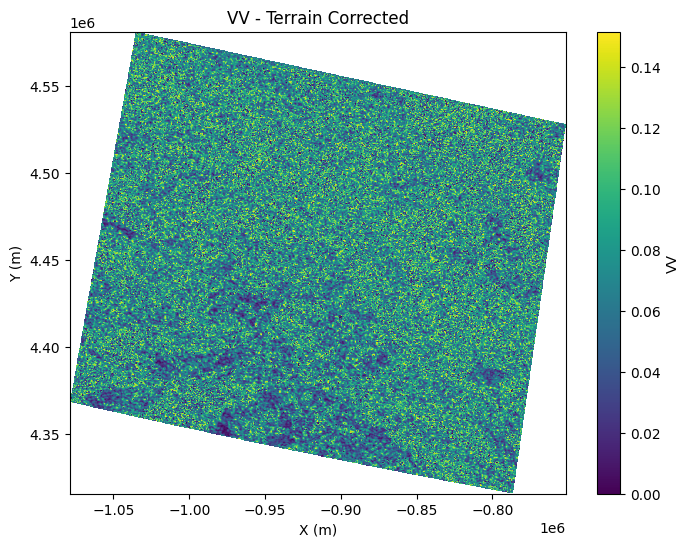

In [34]:
import matplotlib.pyplot as plt

# Choose the band you want to plot, e.g., "VV"
band = "VV"

corrected_ds[band].plot(
    figsize=(8, 6),
    cmap="viridis"
)
plt.title(f"{band} - Terrain Corrected")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()
